In [1]:
import numpy as np
import colour

def wavelength_to_rgb(lam_nm):
    
    # Outside visible range
    if lam_nm < 380 or lam_nm > 780:
        return np.array([0.0, 0.0, 0.0])
    
    # Convert wavelength → XYZ
    XYZ = colour.wavelength_to_XYZ(lam_nm)
    
    # XYZ → sRGB
    rgb = colour.XYZ_to_sRGB(XYZ)
    
    # Clip invalid values
    rgb = np.clip(rgb, 0, 1)
    
    return rgb




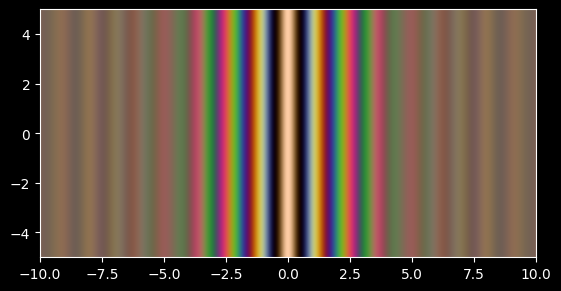

In [2]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")
x=np.linspace(-10,10,20000)
y=np.linspace(-5,5,100)

X,Y=np.meshgrid(x,y)

D=100
d=5e-5

whitel=np.linspace(400,700,100)

RGB_total = np.zeros((len(y), len(x), 3))
for n in whitel:
    λ=n*1e-9

    φ=((d*2*np.pi)/(λ*D))*X

    I=4*((np.cos(φ/2))**2)

    # Normalize intensity (VERY IMPORTANT)
    I = I / I.max()

    # Your chosen base colour (example: blue)
    rgb = wavelength_to_rgb(n)   # custom colour
      
    # Create RGB image
    RGB_total += I[:, :, None] * rgb
    


# Plot
RGB_total /= RGB_total.max()
plt.imshow(RGB_total, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')

plt.savefig("YDSE.pdf")
plt.show()
